## 1. Import Libraries

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

### Library for Machine Learning

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score

## 2. Load and explore dataset

In [5]:
Data = pd.read_csv("agri_classification.csv")

In [6]:
#display top first-five rows
Data.head()

,Region,Season,Rainfall_mm,Temperature_C,Humidity_pct,SoilMoisture_pct,Sunlight_hours,Soil_pH,SoilN_kg_ha,SoilP_kg_ha,SoilK_kg_ha,RecommendedCrop
0,East,Dry,120.72,29.22,55.34,25.33,7.55,6.30,60.0,13.9,60.3,Soybean
1,West,Inter-monsoon,57.34,27.82,80.55,36.49,5.47,7.46,63.1,30.4,75.4,Rice
2,North,Dry,47.72,27.61,70.72,8.49,6.02,5.84,35.9,52.5,71.5,Chili
3,Borneo,Dry,15.91,28.31,63.83,47.48,7.87,7.64,64.7,36.2,48.8,Rice
4,East,Inter-monsoon,111.56,33.10,55.94,33.80,6.62,5.68,36.1,22.4,40.5,Maize


In [7]:
#display top bottom-five rows
Data.tail()

,Region,Season,Rainfall_mm,Temperature_C,Humidity_pct,SoilMoisture_pct,Sunlight_hours,Soil_pH,SoilN_kg_ha,SoilP_kg_ha,SoilK_kg_ha,RecommendedCrop
1195,West,Dry,109.52,26.29,53.05,31.27,7.29,6.52,60.8,28.0,56.6,Maize
1196,North,Dry,94.55,25.28,69.32,33.33,9.19,6.24,45.4,24.0,52.9,Maize
1197,North,Inter-monsoon,163.54,29.02,82.42,19.36,9.25,5.79,24.5,26.2,58.2,Chili
1198,East,Inter-monsoon,120.25,30.02,61.58,33.16,6.85,6.46,65.8,31.5,33.6,Wheat
1199,West,Wet,255.50,27.47,100.00,32.31,5.75,5.91,56.9,30.1,22.4,Rice


In [8]:
#sorting based on label
Data.sample(n=5).sort_index(ascending=True)

,Region,Season,Rainfall_mm,Temperature_C,Humidity_pct,SoilMoisture_pct,Sunlight_hours,Soil_pH,SoilN_kg_ha,SoilP_kg_ha,SoilK_kg_ha,RecommendedCrop
22,South,Dry,62.19,22.96,62.31,18.13,8.89,5.29,67.8,17.7,43.5,Maize
475,Borneo,Dry,85.15,29.78,59.75,41.00,9.25,5.81,61.4,28.8,74.6,Rice
644,South,Wet,187.85,26.14,91.74,50.49,6.98,5.40,93.3,21.7,37.5,Rice
1038,South,Wet,221.55,30.62,83.26,39.93,3.24,6.95,37.4,48.6,48.3,Rice
1166,Borneo,Wet,263.79,30.72,83.40,52.08,4.89,4.83,30.8,32.3,50.0,Rice


## 3. Pre-Processing or Exploratory Data Analysis (EDA)

### 1. View the columns and Rows

In [9]:
print('The number of attributes/features agri_classification.csv  in  is {col}'.format(col=Data.shape[1]))
print('The number of records in agri_classification.csv is {row}'.format(row=Data.shape[0]))

The number of attributes/features agri_classification.csv  in  is 12
The number of records in agri_classification.csv is 1200


### 2. Names of attributes

In [10]:
print('Names of columns in agri_classification.csv is = {col}'.format(col=Data.columns))

Names of columns in agri_classification.csv is = Index(['Region', 'Season', 'Rainfall_mm', 'Temperature_C', 'Humidity_pct',
       'SoilMoisture_pct', 'Sunlight_hours', 'Soil_pH', 'SoilN_kg_ha',
       'SoilP_kg_ha', 'SoilK_kg_ha', 'RecommendedCrop'],
      dtype='object')


### 3. Display information of dataset

In [11]:
#Info() is to provide information about the objects' properties, attributes, methods and datatypes
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Region            1200 non-null   object 
 1   Season            1200 non-null   object 
 2   Rainfall_mm       1200 non-null   float64
 3   Temperature_C     1200 non-null   float64
 4   Humidity_pct      1200 non-null   float64
 5   SoilMoisture_pct  1200 non-null   float64
 6   Sunlight_hours    1200 non-null   float64
 7   Soil_pH           1200 non-null   float64
 8   SoilN_kg_ha       1200 non-null   float64
 9   SoilP_kg_ha       1200 non-null   float64
 10  SoilK_kg_ha       1200 non-null   float64
 11  RecommendedCrop   1200 non-null   object 
dtypes: float64(9), object(3)
memory usage: 112.6+ KB


### 4. Checking the Missing Values and count the number of missing values in each columns

In [12]:
Data.isnull().any()

Region              False
Season              False
Rainfall_mm         False
Temperature_C       False
Humidity_pct        False
SoilMoisture_pct    False
Sunlight_hours      False
Soil_pH             False
SoilN_kg_ha         False
SoilP_kg_ha         False
SoilK_kg_ha         False
RecommendedCrop     False
dtype: bool

### 5. count the missing values/records

In [13]:
Data.isnull().sum()

Region              0
Season              0
Rainfall_mm         0
Temperature_C       0
Humidity_pct        0
SoilMoisture_pct    0
Sunlight_hours      0
Soil_pH             0
SoilN_kg_ha         0
SoilP_kg_ha         0
SoilK_kg_ha         0
RecommendedCrop     0
dtype: int64

### 6. Duplicate values

In [14]:
Data.duplicated().all()

np.False_

### 7. Set decimal places for float data types

In [15]:
Data.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Rainfall_mm,1200.0,136.97,78.64,0.00,73.15,122.74,191.18,361.43
Temperature_C,1200.0,27.09,3.08,17.29,24.98,27.04,29.20,36.00
Humidity_pct,1200.0,73.05,14.08,30.00,63.18,74.24,84.24,100.00
SoilMoisture_pct,1200.0,34.22,13.64,5.00,24.52,33.64,43.50,78.65
Sunlight_hours,1200.0,7.02,1.63,2.59,5.80,6.97,8.14,12.00
Soil_pH,1200.0,6.33,0.70,4.50,5.85,6.34,6.79,8.50
SoilN_kg_ha,1200.0,59.55,19.45,5.00,46.10,59.50,72.03,118.20
SoilP_kg_ha,1200.0,35.07,11.71,5.00,27.50,35.30,42.92,70.90
SoilK_kg_ha,1200.0,45.07,14.39,5.00,35.48,44.90,54.70,95.60


### 8. Set decimal places for float data types

In [16]:
Data['RecommendedCrop'].value_counts().sort_index(ascending=True)

RecommendedCrop
Chili      149
Maize      162
Rice       493
Soybean    259
Tomato      30
Wheat      107
Name: count, dtype: int64

### 9.Grouped Summary Table (Descriptive Statistics by Crop)

In [17]:
summary = Data.groupby("RecommendedCrop").agg(
    MostRegion = ('Region', lambda x: x.mode()[0]),
    MostSeason = ('Season', lambda x: x.mode()[0]),
    
    MeanRainfall = ('Rainfall_mm', 'mean'),
    MeanTemp = ('Temperature_C', 'mean'),
    MeanHumidity = ('Humidity_pct', 'mean'),
    MeanpH = ('Soil_pH', 'mean'),
)

summary

,MostRegion,MostSeason,MeanRainfall,MeanTemp,MeanHumidity,MeanpH
RecommendedCrop,,,,,,
Chili,South,Dry,54.910872,27.039933,62.322282,6.035906
Maize,North,Inter-monsoon,108.639012,25.202778,67.617654,6.247963
Rice,East,Wet,194.647647,27.670446,80.172434,6.176897
Soybean,West,Inter-monsoon,123.204015,27.150656,73.639768,6.643977
Tomato,Borneo,Dry,68.421000,24.950667,60.860667,6.418000
Wheat,East,Dry,80.955514,27.766822,65.370748,6.731215


## 4.Visualize the Data

C:\Users\aaron\AppData\Local\Temp\ipykernel_27352\113390818.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='RecommendedCrop', data=Data, palette='bright')


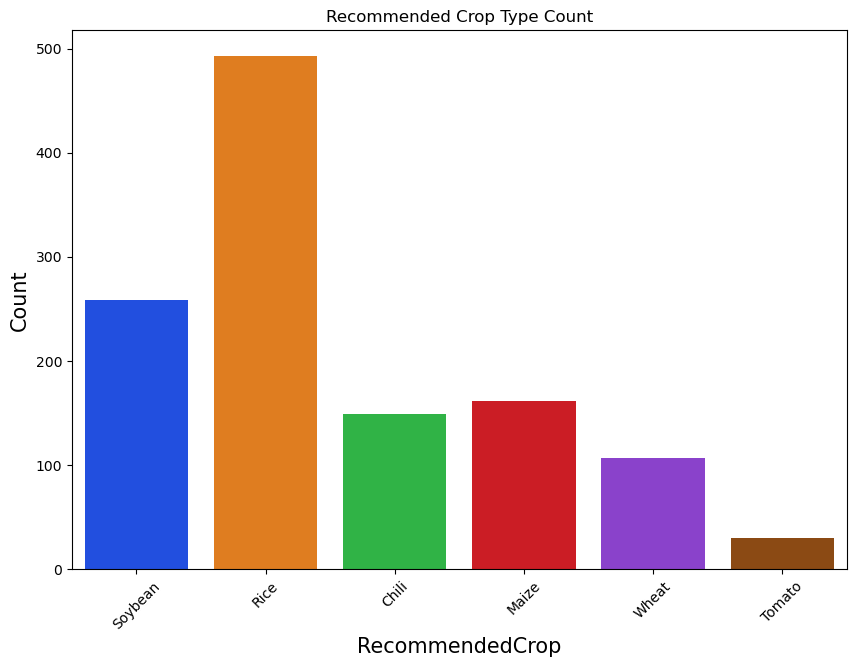

In [18]:
plt.figure(figsize=(10,7))
plt.title('Recommended Crop Type Count')

sns.countplot(x='RecommendedCrop', data=Data, palette='bright')

plt.xticks(rotation=45)
plt.xlabel('RecommendedCrop', fontsize=15)
plt.ylabel('Count', fontsize=15)

# show the graph
plt.show()


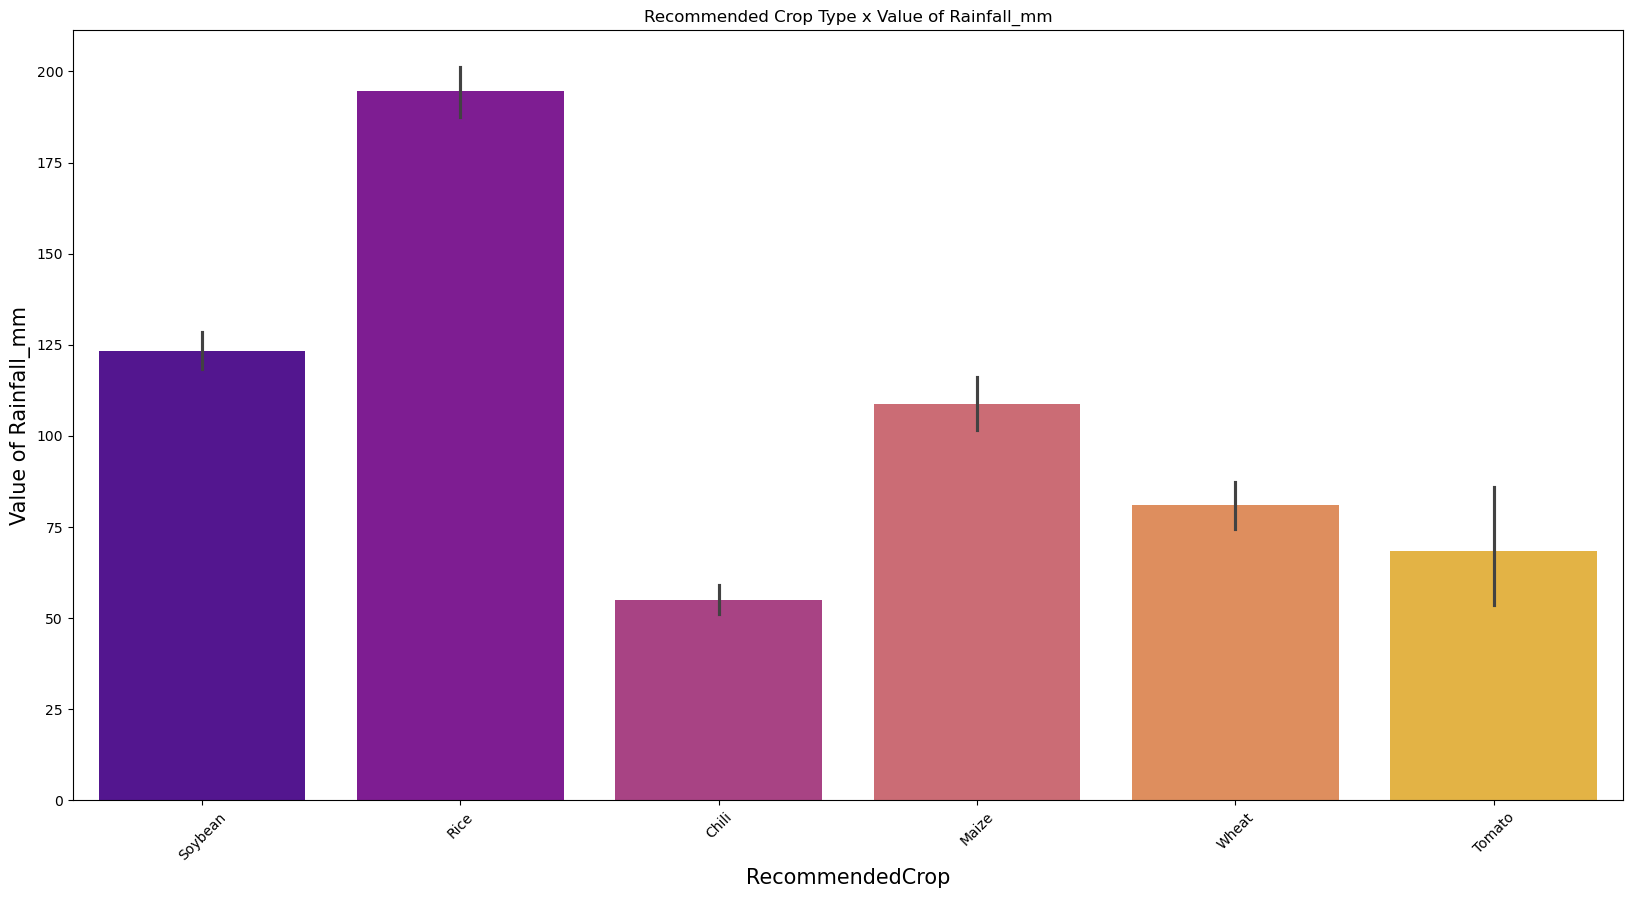

In [20]:
X = Data['RecommendedCrop']
Y = Data['Rainfall_mm']

plt.figure(figsize=(20,10))
plt.title('Recommended Crop Type x Value of Rainfall_mm')
sns.barplot(x=X, y=Y, data=Data, hue='RecommendedCrop', palette='plasma')
plt.xticks(rotation=45)
plt.xlabel('RecommendedCrop', fontsize=15)
plt.ylabel('Value of Rainfall_mm', fontsize=15)

# show the graph
plt.show()

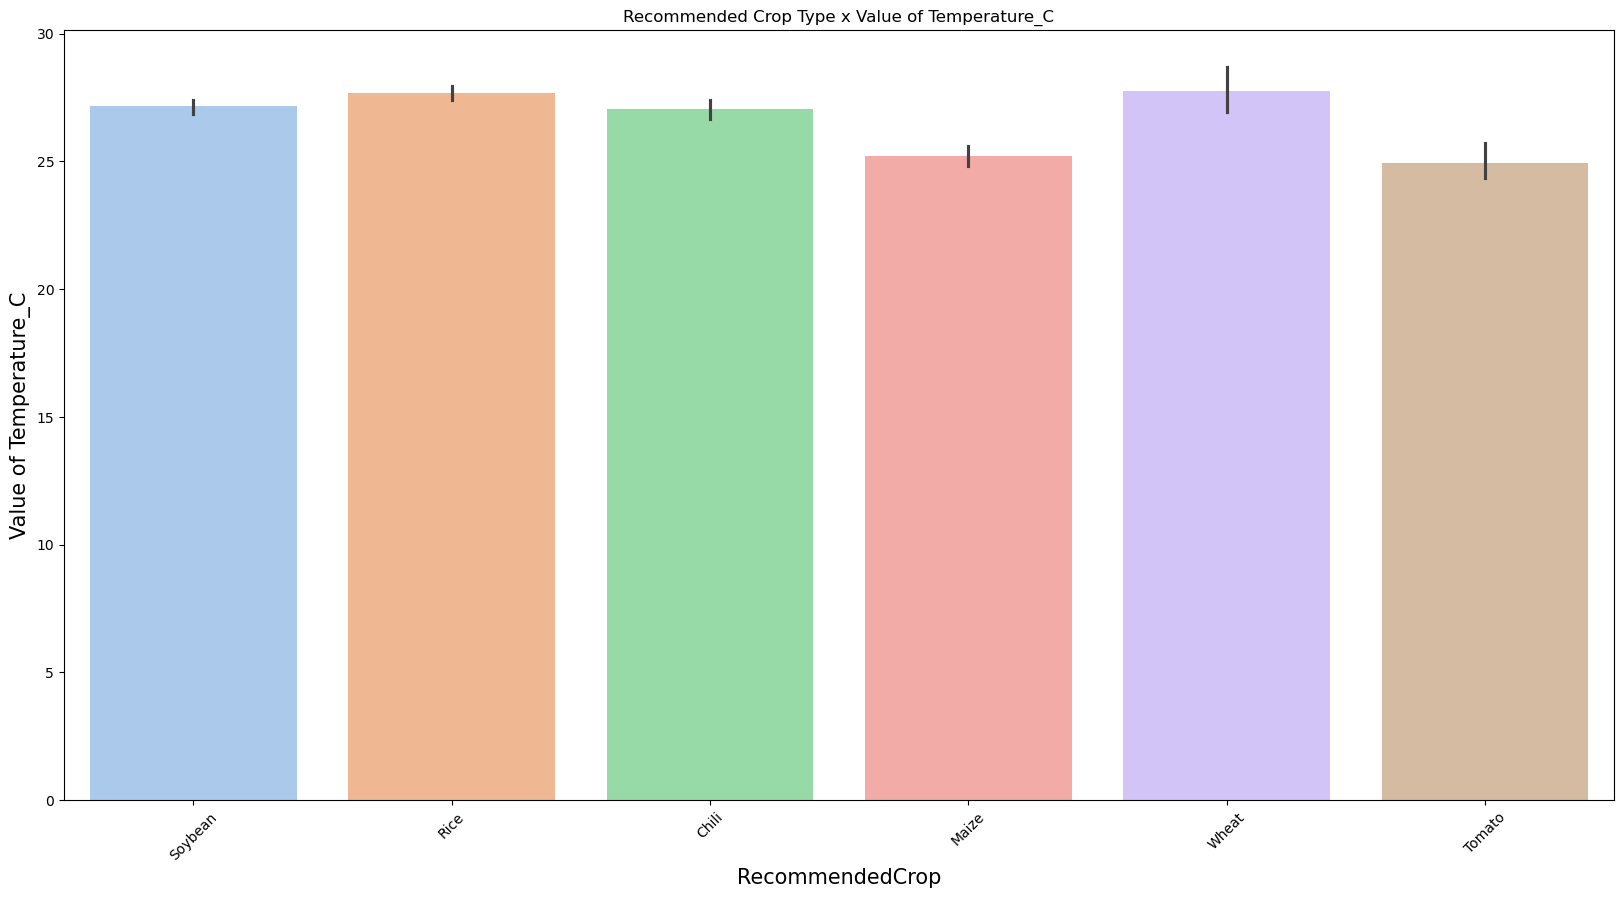

In [21]:
X = Data['RecommendedCrop']
Y = Data['Temperature_C']

plt.figure(figsize=(20,10))
plt.title('Recommended Crop Type x Value of Temperature_C')
sns.barplot(x=X, y=Y, data=Data, hue='RecommendedCrop', palette='pastel')
plt.xticks(rotation=45)
plt.xlabel('RecommendedCrop', fontsize=15)
plt.ylabel('Value of Temperature_C', fontsize=15)

# show the graph
plt.show()


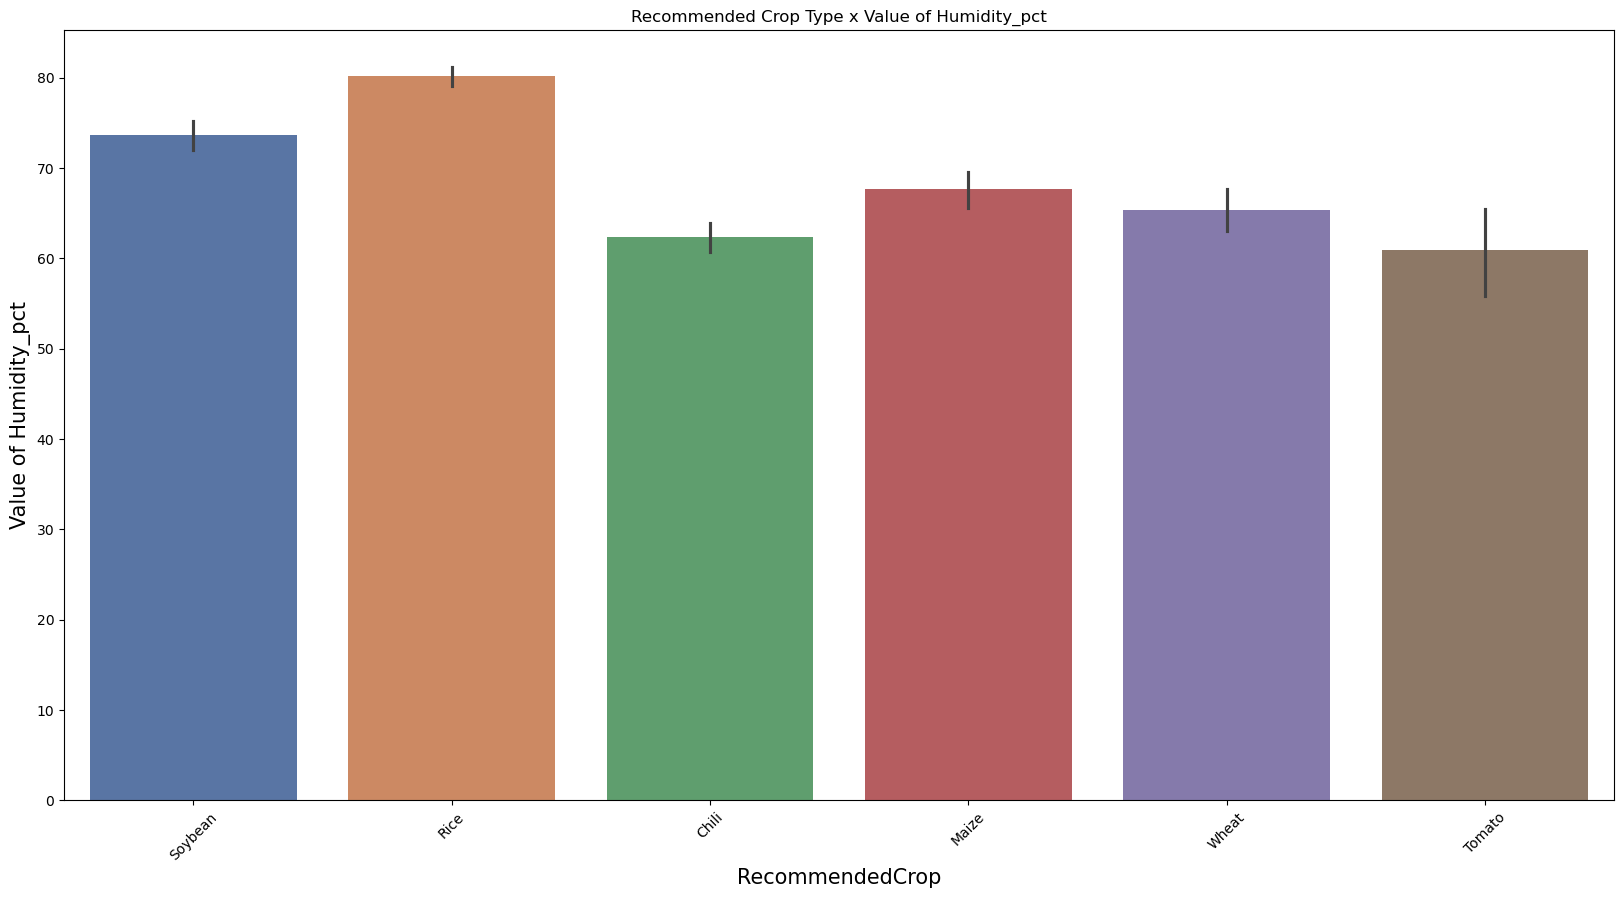

In [22]:
X = Data['RecommendedCrop']
Y = Data['Humidity_pct']

plt.figure(figsize=(20,10))
plt.title('Recommended Crop Type x Value of Humidity_pct')
sns.barplot(x=X, y=Y, data=Data, hue='RecommendedCrop', palette='deep')
plt.xticks(rotation=45)
plt.xlabel('RecommendedCrop', fontsize=15)
plt.ylabel('Value of Humidity_pct', fontsize=15)

# show the graph
plt.show()


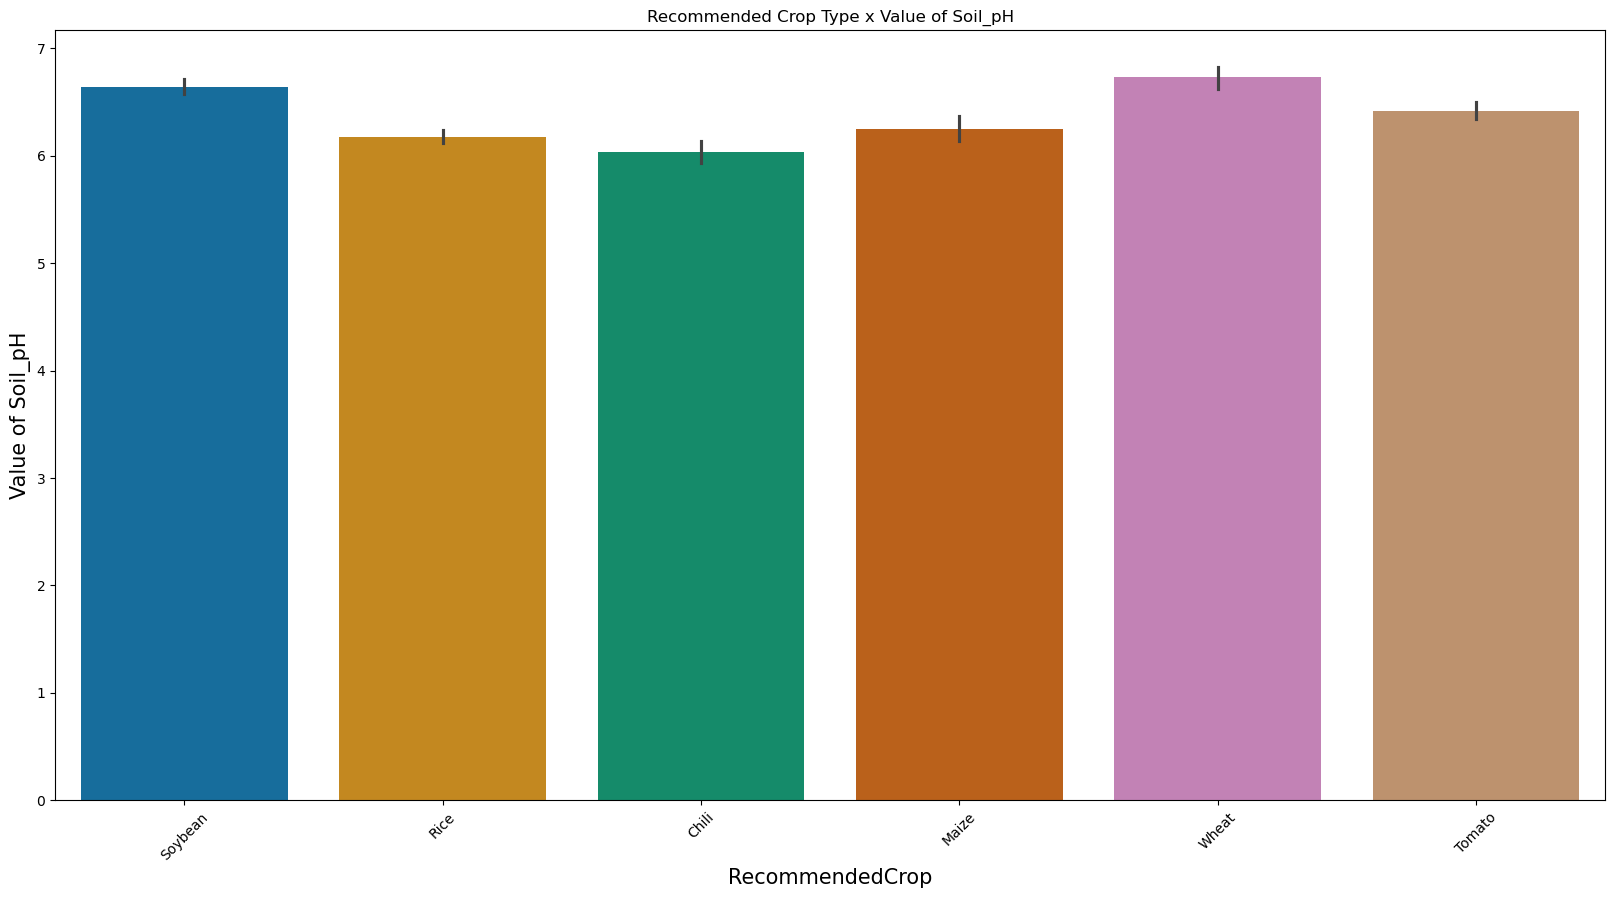

In [23]:
X = Data['RecommendedCrop']
Y = Data['Soil_pH']

plt.figure(figsize=(20,10))
plt.title('Recommended Crop Type x Value of Soil_pH')
sns.barplot(x=X, y=Y, data=Data, hue='RecommendedCrop', palette='colorblind')
plt.xticks(rotation=45)
plt.xlabel('RecommendedCrop', fontsize=15)
plt.ylabel('Value of Soil_pH', fontsize=15)

# show the graph
plt.show()


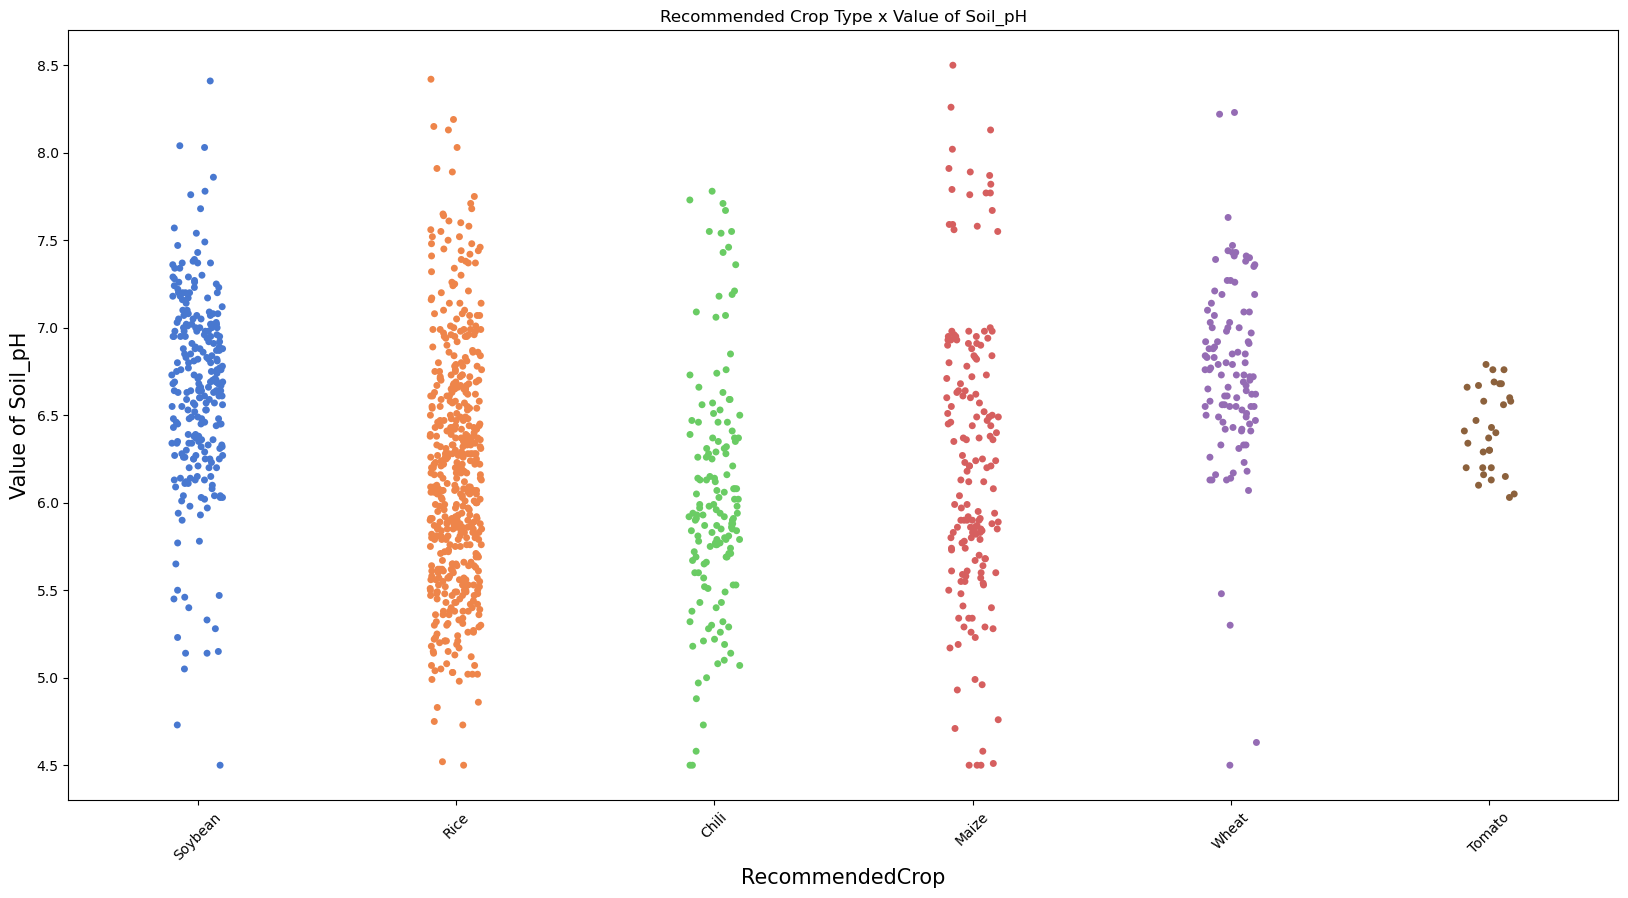

In [24]:
# stripplot()
X = Data['RecommendedCrop']
Y = Data['Soil_pH']

plt.figure(figsize=(20,10))
plt.title('Recommended Crop Type x Value of Soil_pH')
sns.stripplot(x=X, y=Y, data=Data, hue='RecommendedCrop', palette='muted')
plt.xticks(rotation=45)
plt.xlabel('RecommendedCrop', fontsize=15)
plt.ylabel('Value of Soil_pH', fontsize=15)

#show the graph
plt.show()


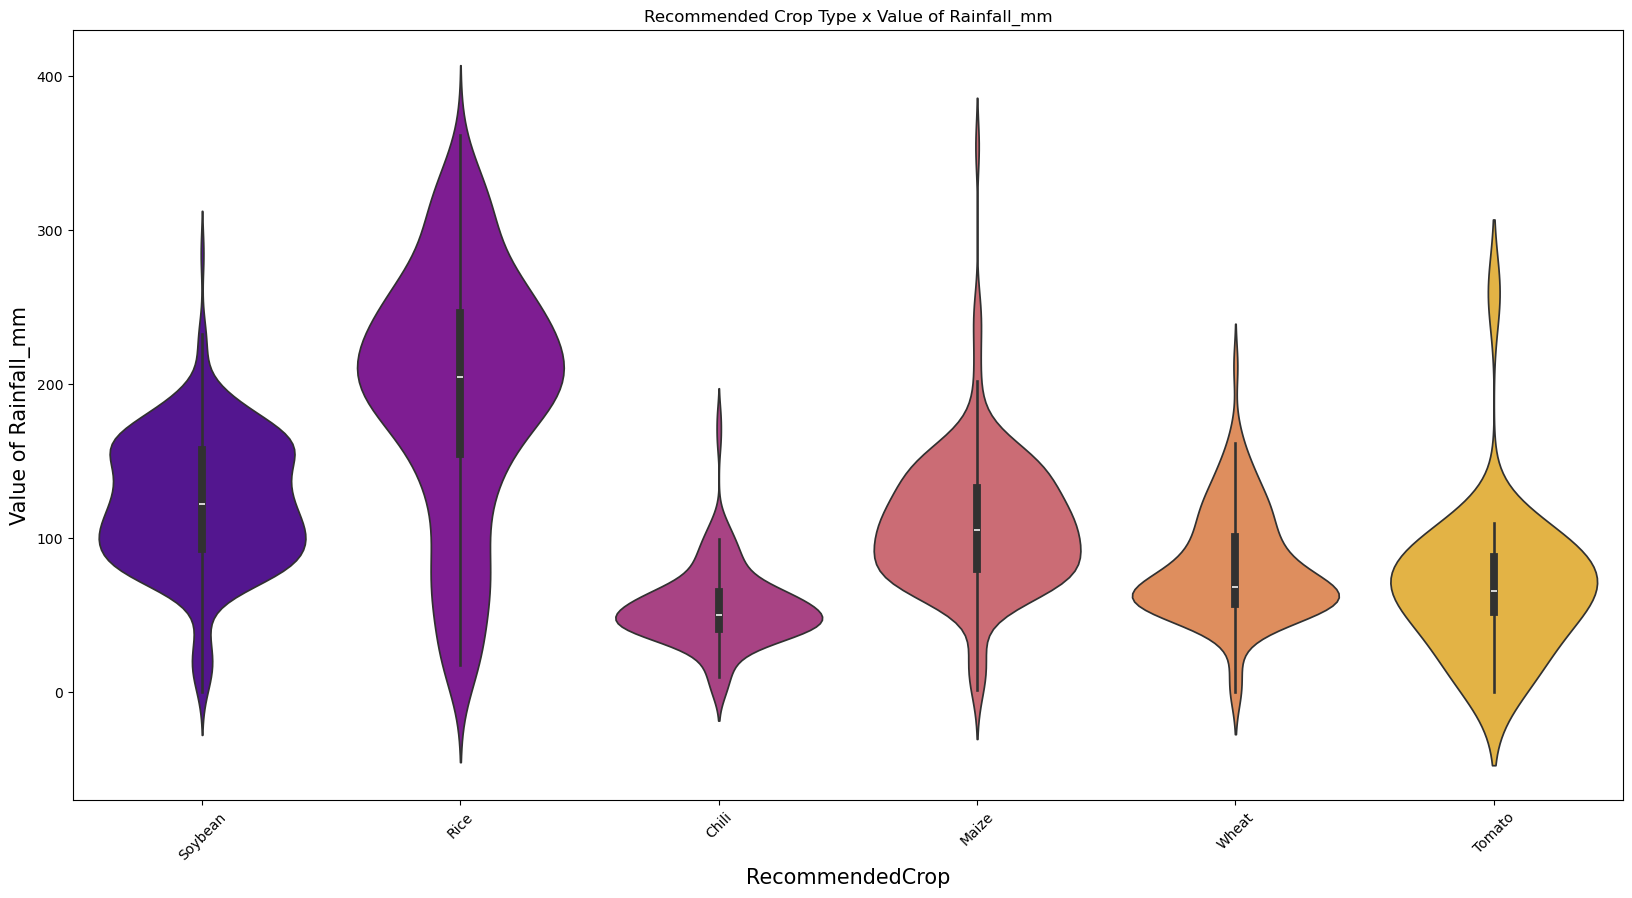

In [25]:
# violinplot()
X = Data['RecommendedCrop']
Y = Data['Rainfall_mm']

plt.figure(figsize=(20,10))
plt.title('Recommended Crop Type x Value of Rainfall_mm')
sns.violinplot(x=X, y=Y, data=Data, hue='RecommendedCrop', palette='plasma')
plt.xticks(rotation=45)
plt.xlabel('RecommendedCrop', fontsize=15)
plt.ylabel('Value of Rainfall_mm', fontsize=15)

#show the graph
plt.show()


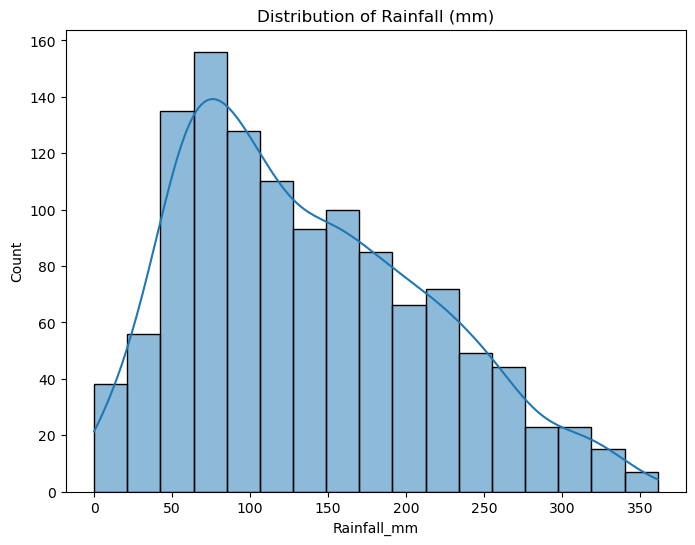

In [26]:
# hist()
plt.figure(figsize=(8, 6))
sns.histplot(Data['Rainfall_mm'], kde=True)
plt.title('Distribution of Rainfall (mm)')
plt.xlabel('Rainfall_mm')
plt.show()


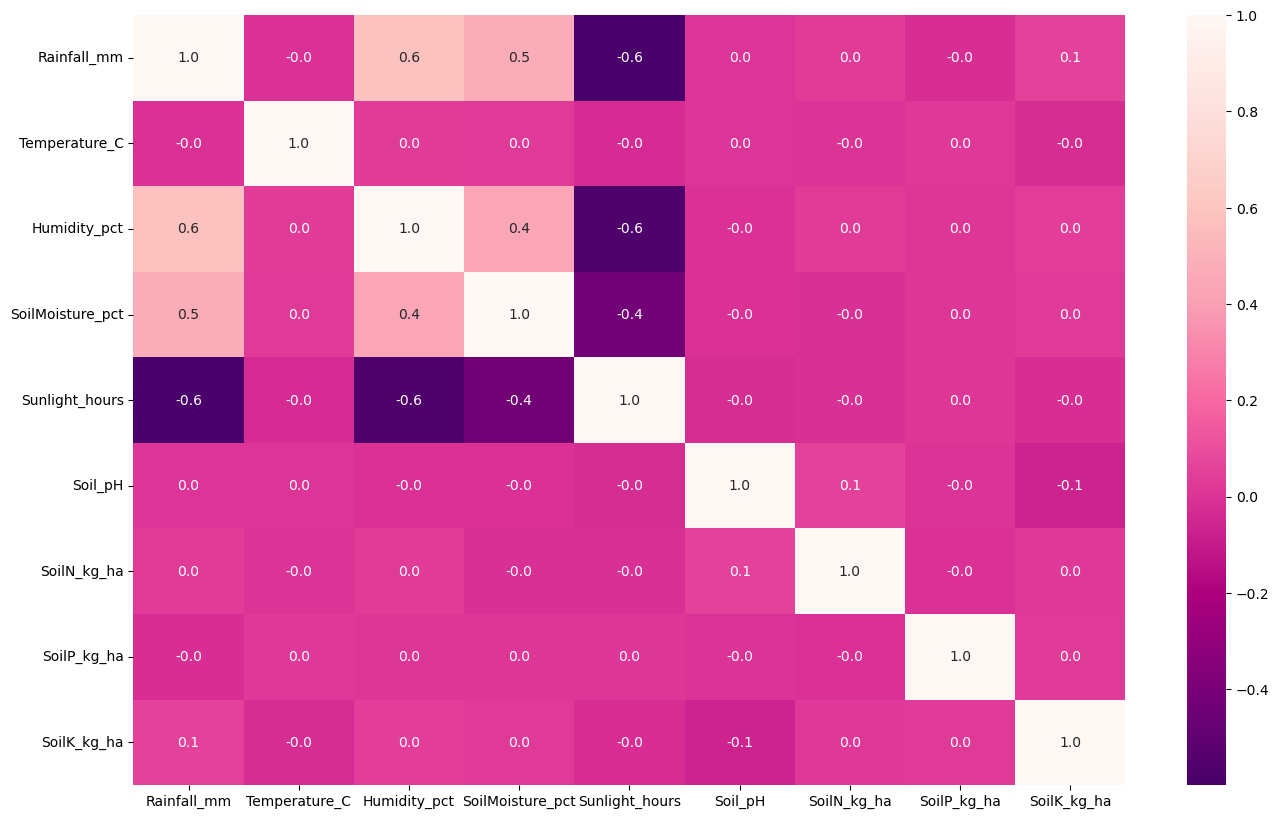

In [27]:
# heatmap()
cr = Data.corr(numeric_only=True)

plt.figure(figsize=(16,10))
sns.heatmap(cr, annot=True, fmt='.1f', cmap='RdPu_r')
plt.show()


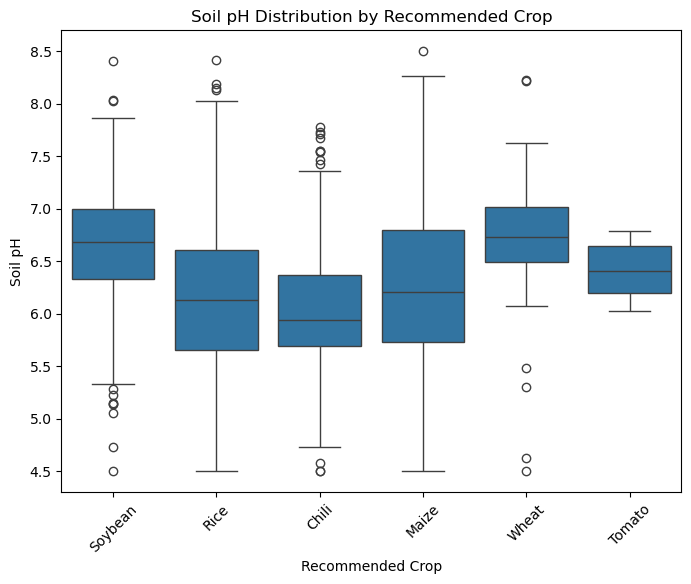

In [28]:
# Box plot for Soil_pH by RecommendedCrop
plt.figure(figsize=(8, 6))
sns.boxplot(x='RecommendedCrop', y='Soil_pH', data=Data)
plt.title('Soil pH Distribution by Recommended Crop')
plt.xlabel('Recommended Crop')
plt.ylabel('Soil pH')
plt.xticks(rotation=45)
plt.show()


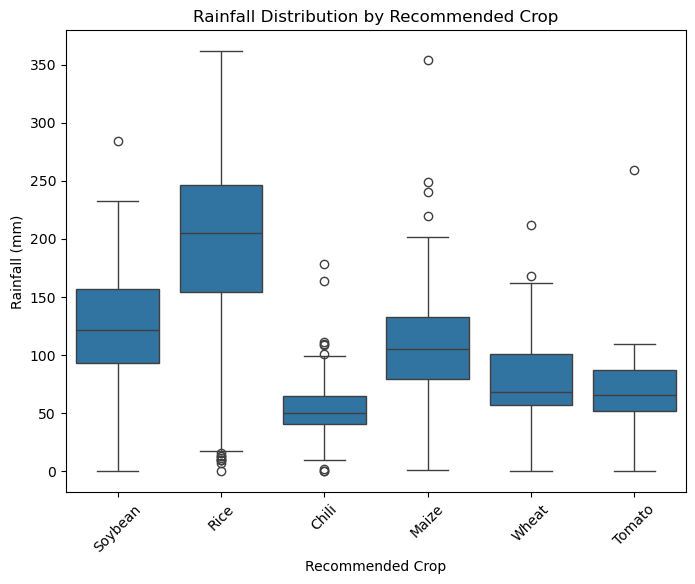

In [29]:
# Box plot for Rainfall by RecommendedCrop
plt.figure(figsize=(8, 6))
sns.boxplot(x='RecommendedCrop', y='Rainfall_mm', data=Data)
plt.title('Rainfall Distribution by Recommended Crop')
plt.xlabel('Recommended Crop')
plt.ylabel('Rainfall (mm)')
plt.xticks(rotation=45)
plt.show()


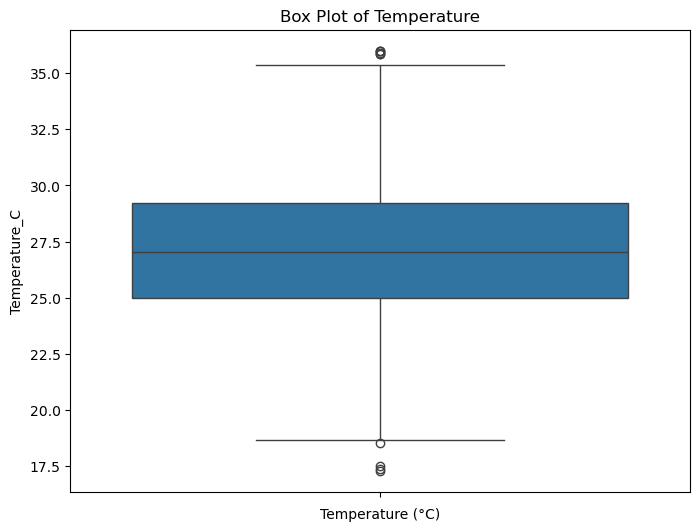

In [30]:
# Box plot to visualize outliers in Temperature_C
plt.figure(figsize=(8, 6))
sns.boxplot(Data['Temperature_C'])
plt.title('Box Plot of Temperature')
plt.xlabel('Temperature (°C)')
plt.show()


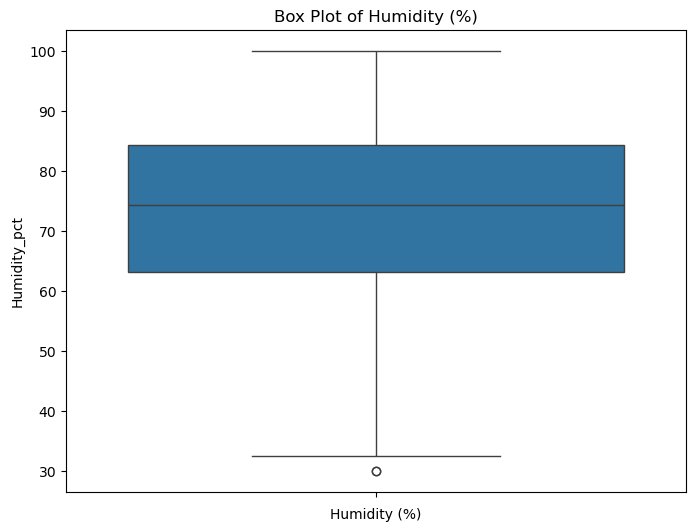

In [31]:
# Box plot to visualize outliers in Humidity_pct
plt.figure(figsize=(8, 6))
sns.boxplot(Data['Humidity_pct'])
plt.title('Box Plot of Humidity (%)')
plt.xlabel('Humidity (%)')
plt.show()


## 5. Create Machine Learning Model 

In [27]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Region            1200 non-null   object 
 1   Season            1200 non-null   object 
 2   Rainfall_mm       1200 non-null   float64
 3   Temperature_C     1200 non-null   float64
 4   Humidity_pct      1200 non-null   float64
 5   SoilMoisture_pct  1200 non-null   float64
 6   Sunlight_hours    1200 non-null   float64
 7   Soil_pH           1200 non-null   float64
 8   SoilN_kg_ha       1200 non-null   float64
 9   SoilP_kg_ha       1200 non-null   float64
 10  SoilK_kg_ha       1200 non-null   float64
 11  RecommendedCrop   1200 non-null   object 
dtypes: float64(9), object(3)
memory usage: 112.6+ KB


### Data Preperation / Data Splitting / Normalization

In [28]:
X = Data[['Region', 'Season',
          'Rainfall_mm', 'Temperature_C',
          'Humidity_pct', 'Soil_pH']]

y = Data['RecommendedCrop']

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# ===========================
# 1. Split Data (80:20)
# ===========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

# ===========================
# 2. One-hot Encoding
# ===========================
X_train = pd.get_dummies(X_train, columns=['Region', 'Season'])
X_test  = pd.get_dummies(X_test,  columns=['Region', 'Season'])

# Ensure same columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# ===========================
# 3. Normalization (Scaling)
# ===========================
numeric_cols = ['Rainfall_mm', 'Temperature_C', 'Humidity_pct', 'Soil_pH']

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


In [29]:
X_train.head()

,Rainfall_mm,Temperature_C,Humidity_pct,Soil_pH,Region_Borneo,Region_East,Region_North,Region_South,Region_West,Season_Dry,Season_Inter-monsoon,Season_Wet
959,-0.708144,-0.637799,-1.731760,-2.213595,False,False,False,False,True,True,False,False
951,0.138683,-0.608638,0.332356,0.351625,False,True,False,False,False,False,True,False
831,-0.240107,-0.174458,-0.256988,-1.008933,False,False,False,True,False,False,True,False
1186,0.091000,1.397012,0.113295,0.167383,True,False,False,False,False,False,False,True
745,0.338979,-0.560036,1.238277,-0.994761,True,False,False,False,False,False,True,False


### First Algorithm (Decision Tree)

In [30]:
# ============================================
# First Algorithm (Decision Tree)
# ============================================
decision_tree_model = DecisionTreeClassifier()

decision_tree_model.fit(X_train, y_train)       # training
y_pred_dt = decision_tree_model.predict(X_test) # prediction

cm = confusion_matrix(y_test, y_pred_dt)
cr = classification_report(y_test, y_pred_dt)

print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", cr)

accuracy = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy of Decision Tree Model is {accuracy:.2f}")


Confusion Matrix:
 [[18  1  4  1  3  3]
 [ 4 12  6  5  4  1]
 [ 5  4 72 15  2  1]
 [ 2  6 10 31  2  1]
 [ 1  0  2  2  1  0]
 [ 1  2  3  1  0 14]]

Classification Report:
               precision    recall  f1-score   support

       Chili       0.58      0.60      0.59        30
       Maize       0.48      0.38      0.42        32
        Rice       0.74      0.73      0.73        99
     Soybean       0.56      0.60      0.58        52
      Tomato       0.08      0.17      0.11         6
       Wheat       0.70      0.67      0.68        21

    accuracy                           0.62       240
   macro avg       0.52      0.52      0.52       240
weighted avg       0.63      0.62      0.62       240

Accuracy of Decision Tree Model is 0.62


### Second Algorithm (Random Forest)

In [31]:
# ============================================
# Second Algorithm (Random Forest)
# ============================================

# 1. Create Model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# 2. Train the data
rf_model.fit(X_train, y_train)

# 3. Test the data (Prediction model) -- output
y_pred_rf = rf_model.predict(X_test)

# 4. Develop and Perform calculation
cm_rf = confusion_matrix(y_test, y_pred_rf)
cr_rf = classification_report(y_test, y_pred_rf, zero_division=0)

# 5. Display/show the classification result
print('=== Random Forest Classifier ===')
print('\nConfusion Matrix Report:')
print(cm_rf)
print('\nClassification Report:')
print(cr_rf)

# 6. Evaluate the accuracy of model 
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f'Accuracy of Random Forest Model is {accuracy_rf:.2f}')


=== Random Forest Classifier ===

Confusion Matrix Report:
[[21  1  4  1  0  3]
 [ 3 16  1 11  0  1]
 [ 6  2 83  7  0  1]
 [ 1  5 10 34  1  1]
 [ 0  2  0  2  0  2]
 [ 0  2  5  1  0 13]]

Classification Report:
              precision    recall  f1-score   support

       Chili       0.68      0.70      0.69        30
       Maize       0.57      0.50      0.53        32
        Rice       0.81      0.84      0.82        99
     Soybean       0.61      0.65      0.63        52
      Tomato       0.00      0.00      0.00         6
       Wheat       0.62      0.62      0.62        21

    accuracy                           0.70       240
   macro avg       0.55      0.55      0.55       240
weighted avg       0.68      0.70      0.69       240

Accuracy of Random Forest Model is 0.70


### Third Algorithm (Logistic Regression)


In [32]:
# ============================================
# Third Algorithm (Logistic Regression)
# ============================================

# 1. Create Model
log_model = LogisticRegression(
    max_iter=2000,          # allow enough iterations to converge
    multi_class='multinomial'  # handle multi-class crops
)

# 2. Train the data
log_model.fit(X_train, y_train)

# 3. Test the data (Prediction model) -- output
y_pred_log = log_model.predict(X_test)

# 4. Develop and Perform calculation
cm_log = confusion_matrix(y_test, y_pred_log)
cr_log = classification_report(y_test, y_pred_log, zero_division=0)

# 5. Display/show the classification result
print('=== Logistic Regression ===')
print('\nConfusion Matrix Report:')
print(cm_log)
print('\nClassification Report:')
print(cr_log)

# 6. Evaluate the accuracy of model 
accuracy_log = accuracy_score(y_test, y_pred_log)
print(f'Accuracy of Logistic Regression Model is {accuracy_log:.2f}')


=== Logistic Regression ===

Confusion Matrix Report:
[[23  1  2  3  0  1]
 [ 5 10  7  6  0  4]
 [ 8  1 83  7  0  0]
 [ 0  3 15 32  0  2]
 [ 2  4  0  0  0  0]
 [ 4  2  2  5  0  8]]

Classification Report:
              precision    recall  f1-score   support

       Chili       0.55      0.77      0.64        30
       Maize       0.48      0.31      0.38        32
        Rice       0.76      0.84      0.80        99
     Soybean       0.60      0.62      0.61        52
      Tomato       0.00      0.00      0.00         6
       Wheat       0.53      0.38      0.44        21

    accuracy                           0.65       240
   macro avg       0.49      0.49      0.48       240
weighted avg       0.62      0.65      0.63       240

Accuracy of Logistic Regression Model is 0.65


C:\Users\aaron\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### Fourth Algorithm (SVM - RBF Kernel)

In [33]:
from sklearn.svm import SVC

# ============================================
# Fourth Algorithm (SVM - RBF Kernel)
# ============================================

# 1. Create Model
svm_model = SVC(
    kernel='rbf',
    random_state=42
)

# 2. Train the data
svm_model.fit(X_train, y_train)

# 3. Test the data (Prediction model) -- output
y_pred_svm = svm_model.predict(X_test)

# 4. Develop and Perform calculation
cm_svm = confusion_matrix(y_test, y_pred_svm)
cr_svm = classification_report(y_test, y_pred_svm, zero_division=0)

# 5. Display/show the classification result
print('=== SVM (RBF Kernel) ===')
print('\nConfusion Matrix Report:')
print(cm_svm)
print('\nClassification Report:')
print(cr_svm)

# 6. Evaluate the accuracy of model 
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f'Accuracy of SVM Model is {accuracy_svm:.2f}')


=== SVM (RBF Kernel) ===

Confusion Matrix Report:
[[19  2  3  4  0  2]
 [ 4 14  3 10  0  1]
 [ 8  3 82  5  0  1]
 [ 0  3 11 35  0  3]
 [ 0  4  0  1  0  1]
 [ 1  2  2  5  0 11]]

Classification Report:
              precision    recall  f1-score   support

       Chili       0.59      0.63      0.61        30
       Maize       0.50      0.44      0.47        32
        Rice       0.81      0.83      0.82        99
     Soybean       0.58      0.67      0.62        52
      Tomato       0.00      0.00      0.00         6
       Wheat       0.58      0.52      0.55        21

    accuracy                           0.67       240
   macro avg       0.51      0.52      0.51       240
weighted avg       0.65      0.67      0.66       240

Accuracy of SVM Model is 0.67


### Model Accuracy Comparison

In [34]:
# ============================================
# Model Accuracy Comparison
# ============================================

print('Comparison of accuracy of DT, RF, LR and SVM')
print('\n')

# Decision Tree
accuracy = accuracy_score(y_test, y_pred_dt)
print(f'Accuracy of Decision Tree Model is {accuracy:.2f}')

# Random Forest
accuracy = accuracy_score(y_test, y_pred_rf)
print(f'Accuracy of Random Forest Model is {accuracy:.2f}')

# Logistic Regression
accuracy = accuracy_score(y_test, y_pred_log)
print(f'Accuracy of Logistic Regression Model is {accuracy:.2f}')

# SVM
accuracy = accuracy_score(y_test, y_pred_svm)
print(f'Accuracy of SVM Model is {accuracy:.2f}')


Comparison of accuracy of DT, RF, LR and SVM


Accuracy of Decision Tree Model is 0.62
Accuracy of Random Forest Model is 0.70
Accuracy of Logistic Regression Model is 0.65
Accuracy of SVM Model is 0.67


### Model Confusion Matrix Comparison

In [35]:
from sklearn.metrics import confusion_matrix

print("=== Confusion Matrices ===")

# Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
print("\nConfusion Matrix (Decision Tree):")
print(cm_dt)

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix (Random Forest):")
print(cm_rf)

# Logistic Regression
cm_log = confusion_matrix(y_test, y_pred_log)
print("\nConfusion Matrix (Logistic Regression):")
print(cm_log)

# SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
print("\nConfusion Matrix (SVM):")
print(cm_svm)


=== Confusion Matrices ===

Confusion Matrix (Decision Tree):
[[18  1  4  1  3  3]
 [ 4 12  6  5  4  1]
 [ 5  4 72 15  2  1]
 [ 2  6 10 31  2  1]
 [ 1  0  2  2  1  0]
 [ 1  2  3  1  0 14]]

Confusion Matrix (Random Forest):
[[21  1  4  1  0  3]
 [ 3 16  1 11  0  1]
 [ 6  2 83  7  0  1]
 [ 1  5 10 34  1  1]
 [ 0  2  0  2  0  2]
 [ 0  2  5  1  0 13]]

Confusion Matrix (Logistic Regression):
[[23  1  2  3  0  1]
 [ 5 10  7  6  0  4]
 [ 8  1 83  7  0  0]
 [ 0  3 15 32  0  2]
 [ 2  4  0  0  0  0]
 [ 4  2  2  5  0  8]]

Confusion Matrix (SVM):
[[19  2  3  4  0  2]
 [ 4 14  3 10  0  1]
 [ 8  3 82  5  0  1]
 [ 0  3 11 35  0  3]
 [ 0  4  0  1  0  1]
 [ 1  2  2  5  0 11]]


### Model Classification Report

In [36]:
from sklearn.metrics import classification_report

print("=== Classification Reports ===")

# Decision Tree
cr_dt = classification_report(y_test, y_pred_dt, zero_division=0)
print("\nClassification Report (Decision Tree):")
print(cr_dt)

# Random Forest
cr_rf = classification_report(y_test, y_pred_rf, zero_division=0)
print("\nClassification Report (Random Forest):")
print(cr_rf)

# Logistic Regression
cr_log = classification_report(y_test, y_pred_log, zero_division=0)
print("\nClassification Report (Logistic Regression):")
print(cr_log)

# SVM
cr_svm = classification_report(y_test, y_pred_svm, zero_division=0)
print("\nClassification Report (SVM):")
print(cr_svm)


=== Classification Reports ===

Classification Report (Decision Tree):
              precision    recall  f1-score   support

       Chili       0.58      0.60      0.59        30
       Maize       0.48      0.38      0.42        32
        Rice       0.74      0.73      0.73        99
     Soybean       0.56      0.60      0.58        52
      Tomato       0.08      0.17      0.11         6
       Wheat       0.70      0.67      0.68        21

    accuracy                           0.62       240
   macro avg       0.52      0.52      0.52       240
weighted avg       0.63      0.62      0.62       240


Classification Report (Random Forest):
              precision    recall  f1-score   support

       Chili       0.68      0.70      0.69        30
       Maize       0.57      0.50      0.53        32
        Rice       0.81      0.84      0.82        99
     Soybean       0.61      0.65      0.63        52
      Tomato       0.00      0.00      0.00         6
       Wheat       0.

### Model Classification Report (Random Forest)

Classification Report for Random Forest:
              precision    recall  f1-score   support

       Chili       0.68      0.70      0.69        30
       Maize       0.57      0.50      0.53        32
        Rice       0.81      0.84      0.82        99
     Soybean       0.61      0.65      0.63        52
      Tomato       0.00      0.00      0.00         6
       Wheat       0.62      0.62      0.62        21

    accuracy                           0.70       240
   macro avg       0.55      0.55      0.55       240
weighted avg       0.68      0.70      0.69       240

Accuracy: 0.6958333333333333

Confusion Matrix:
[[21  1  4  1  0  3]
 [ 3 16  1 11  0  1]
 [ 6  2 83  7  0  1]
 [ 1  5 10 34  1  1]
 [ 0  2  0  2  0  2]
 [ 0  2  5  1  0 13]]


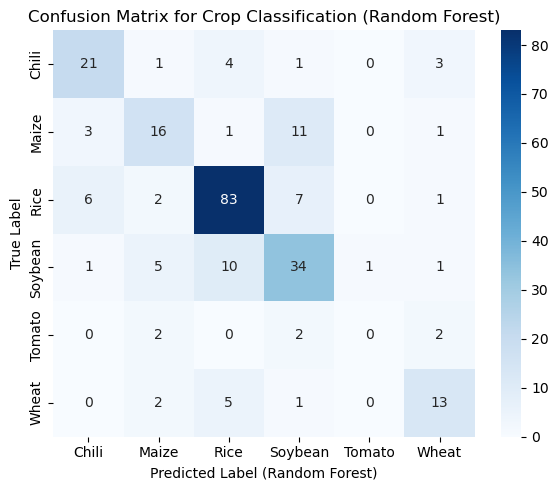

In [44]:
# Get class names from the data (e.g. Rice, Wheat, Corn, Soybean, Chili, ...)
class_names = sorted(y_test.unique())

# ===== Classification Report =====
print("Classification Report for Random Forest:")
print(classification_report(y_test, y_pred_rf,
                            target_names=class_names,
                            zero_division=0))

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

# ===== Confusion Matrix =====
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_rf, labels=class_names)
print(cm)

# Heatmap for Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label (Random Forest)')
plt.ylabel('True Label')
plt.title("Confusion Matrix for Crop Classification (Random Forest)")
plt.tight_layout()
plt.show()

# ===== Save Detailed Report to File =====
report = classification_report(y_test, y_pred_rf,
                               target_names=class_names,
                               output_dict=True,
                               zero_division=0)

pd.DataFrame(report).transpose().to_csv('classification_Report_RF.txt')

In [45]:
!pip install joblib

In [48]:
import joblib

# After you finish training:
# X_train is already one-hot encoded with get_dummies
# rf_model is your trained RandomForestClassifier

joblib.dump(rf_model, 'best_model.pkl')
joblib.dump(list(X_train.columns), 'best_model_columns.pkl')
joblib.dump(scaler, 'best_model_scaler.pkl')


print("Model and feature columns saved.")

Model and feature columns saved.


# User Prompt

In [50]:
import joblib
import pandas as pd

# ==============================
# Load trained model + feature columns + scaler
# ==============================
model = joblib.load('best_model.pkl')                     # trained Random Forest model
feature_cols = joblib.load('best_model_columns.pkl')   # list of columns used in training
scaler = joblib.load('best_model_scaler.pkl')                        # StandardScaler used during training

print("CROP RECOMMENDATION SYSTEM")
print("---------------------------")

while True:
    try:
        print("\n Please enter the environmental features below:")

        # User inputs
        region = input("Region (e.g., East, West, North, South, Borneo): ").strip()
        season = input("Season (Dry, Wet, Inter-monsoon): ").strip()
        rainfall = input("Rainfall (mm): ").replace(',', '.')
        temperature = input("Temperature (°C): ").replace(',', '.')
        humidity = input("Humidity (%): ").replace(',', '.')
        soil_ph = input("Soil pH: ").replace(',', '.')

        # Validate numeric fields
        try:
            rainfall = float(rainfall)
            temperature = float(temperature)
            humidity = float(humidity)
            soil_ph = float(soil_ph)
        except ValueError:
            print("Invalid numeric values detected. Please enter only numbers.")
            continue

        # ==============================
        # Build raw input dataframe
        # ==============================
        user_raw = pd.DataFrame([{
            "Region": region,
            "Season": season,
            "Rainfall_mm": rainfall,
            "Temperature_C": temperature,
            "Humidity_pct": humidity,
            "Soil_pH": soil_ph
        }])

        # ==============================
        # Apply SAME one-hot encoding as training
        # ==============================
        user_encoded = pd.get_dummies(
            user_raw,
            columns=['Region', 'Season']
        )

        # Ensure same columns as training
        user_encoded = user_encoded.reindex(columns=feature_cols, fill_value=0)

        # ==============================
        # Scale numeric columns using SAME scaler
        # ==============================
        numeric_cols = ['Rainfall_mm', 'Temperature_C', 'Humidity_pct', 'Soil_pH']
        user_encoded[numeric_cols] = scaler.transform(user_encoded[numeric_cols])

        # ==============================
        # Predict crop
        # ==============================
        pred_crop = model.predict(user_encoded)[0]

        # ==============================
        # Output result
        # ==============================
        print("----------------------------------------")
        print(f"Predicted Recommended Crop : {pred_crop}")
        print("----------------------------------------")

        again = input("\n Predict another crop? (y/n): ").strip().lower()
        if again != 'y':
            print("Exiting system. Goodbye!")
            break

    except Exception as e:
        print(f"Error: {e}")
        print("Please re-enter your input correctly.\n")


CROP RECOMMENDATION SYSTEM
---------------------------

 Please enter the environmental features below:


Region (e.g., East, West, North, South, Borneo):  East
Season (Dry, Wet, Inter-monsoon):  Wet
Rainfall (mm):  50
Temperature (°C):  25
Humidity (%):  40
Soil pH:  6


----------------------------------------
Predicted Recommended Crop : Rice
----------------------------------------



 Predict another crop? (y/n):  n


Exiting system. Goodbye!


In [80]:
!pip install streamlit

In [54]:
import os
os.getcwd()

'C:\\Users\\aaron\\000 Data Mining'